# 📊 Professional Exploratory Data Analysis (EDA)

This notebook performs a **comprehensive Exploratory Data Analysis (EDA)** on the given dataset (`symptom_precaution.csv`).  

## Steps Covered:
1. Data Overview  
2. Data Quality Check (missing values, duplicates, unique counts)  
3. Descriptive Statistics  
4. Univariate Analysis (distributions & frequency counts)  
5. Bivariate Analysis (correlations & relationships)  
6. Outlier Detection  
7. Missing Data Analysis  
8. Key Insights & Next Steps  

---


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv('..//backend/Training/MasterData/symptom_precaution.csv')
print("Dataset Uploaded Sucessfully!")

Dataset Uploaded Sucessfully!


# Dataset Overview

In [3]:
print("🔹 Dataset Shape:", df.shape)
df.head()

🔹 Dataset Shape: (40, 5)


,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
0,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
1,Allergy,apply calamine,cover area with bandage,,use ice to compress itching
2,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
3,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths
4,GERD,avoid fatty spicy food,avoid lying down after eating,maintain healthy weight,exercise


In [4]:
# Dataset Info & Quality Check
print("\n🔹 Info:")
df.info()


🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Drug Reaction                             40 non-null     object
 1   stop irritation                           40 non-null     object
 2   consult nearest hospital                  40 non-null     object
 3   stop taking drug                          40 non-null     object
 4   follow up                                 39 non-null     object
dtypes: object(5)
memory usage: 1.7+ KB


In [5]:
print("\n🔹 Column Names:", df.columns.tolist())
print("\n🔹 Data Types:\n", df.dtypes)
print("\n🔹 Missing Values:\n", df.isnull().sum())
print("\n🔹 Duplicate Rows:", df.duplicated().sum())


🔹 Column Names: ['Drug Reaction                           ', 'stop irritation                      ', 'consult nearest hospital           ', 'stop taking drug                       ', 'follow up']

🔹 Data Types:
 Drug Reaction                               object
stop irritation                             object
consult nearest hospital                    object
stop taking drug                            object
follow up                                   object
dtype: object

🔹 Missing Values:
 Drug Reaction                               0
stop irritation                             0
consult nearest hospital                    0
stop taking drug                            0
follow up                                   1
dtype: int64

🔹 Duplicate Rows: 0


In [6]:
# Unique values per column
print("\n🔹 Unique Value Counts:")
print(df.nunique())


🔹 Unique Value Counts:
Drug Reaction                               40
stop irritation                             31
consult nearest hospital                    34
stop taking drug                            30
follow up                                   24
dtype: int64


In [7]:
# Descriptive Statistics
df.describe(include="all").transpose()

,count,unique,top,freq
Drug Reaction,40,40,Malaria,1
stop irritation,40,31,Consult nearest hospital,3
consult nearest hospital,40,34,exercise,3
stop taking drug,40,30,consult doctor,6
follow up,39,24,medication,6


C:\Users\hp\AppData\Local\Temp\ipykernel_17528\93040612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


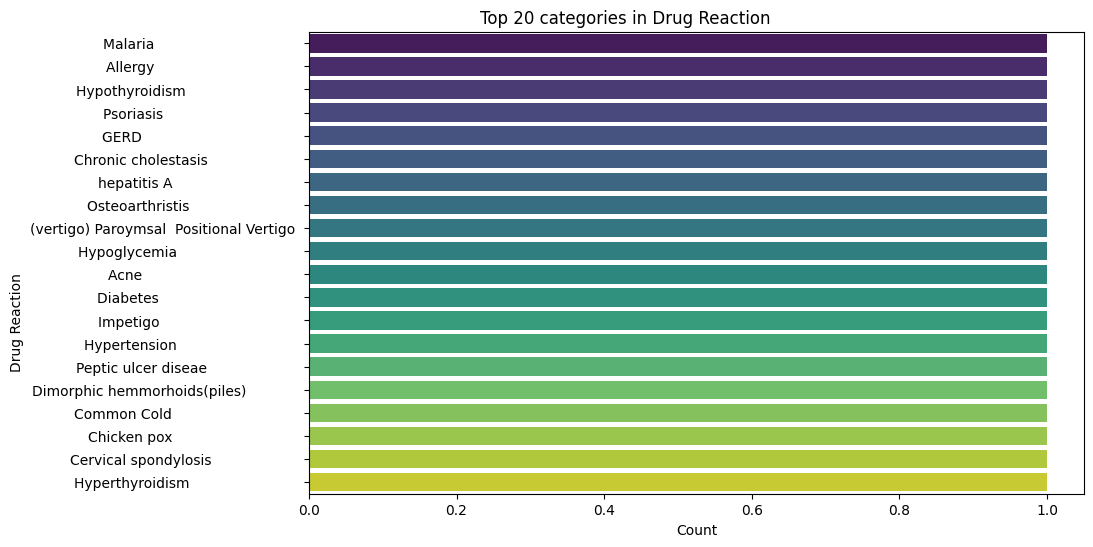

C:\Users\hp\AppData\Local\Temp\ipykernel_17528\93040612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


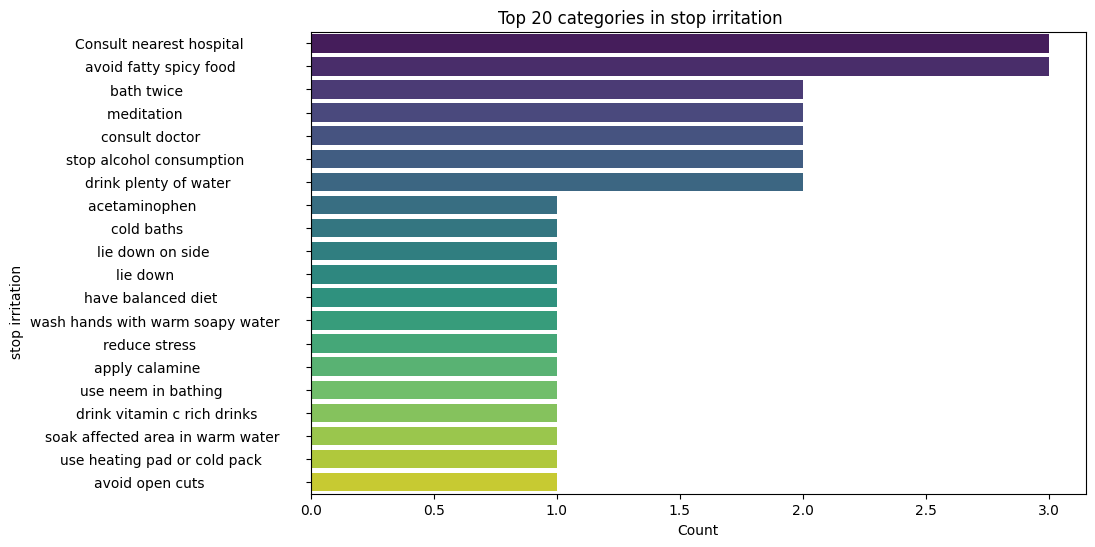

C:\Users\hp\AppData\Local\Temp\ipykernel_17528\93040612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


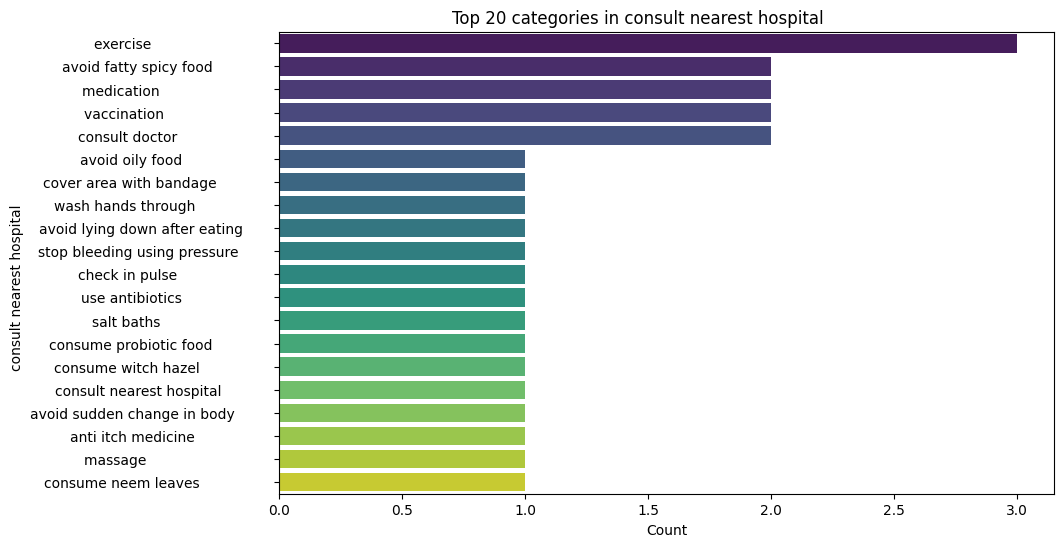

C:\Users\hp\AppData\Local\Temp\ipykernel_17528\93040612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


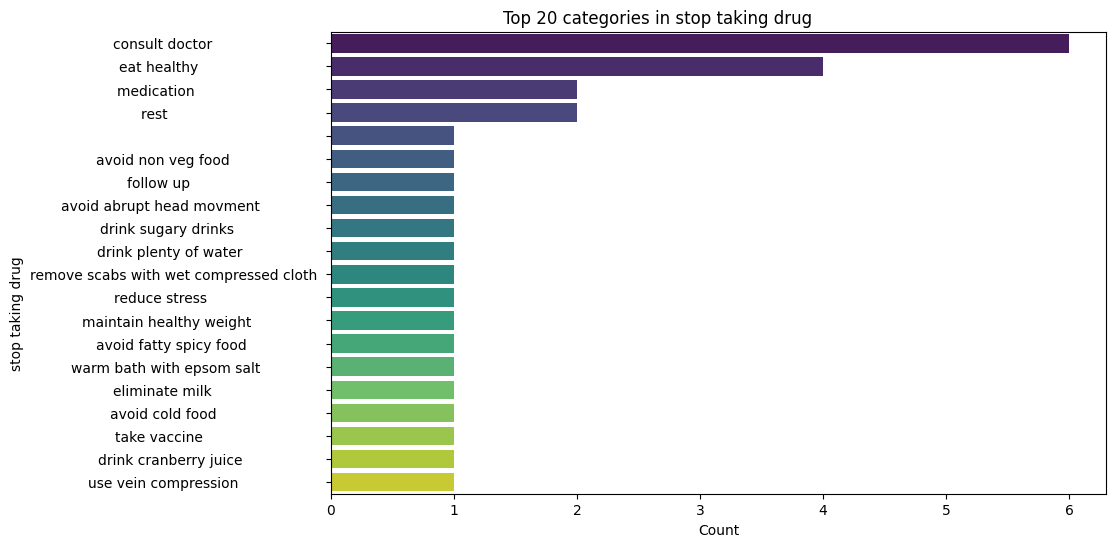

C:\Users\hp\AppData\Local\Temp\ipykernel_17528\93040612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


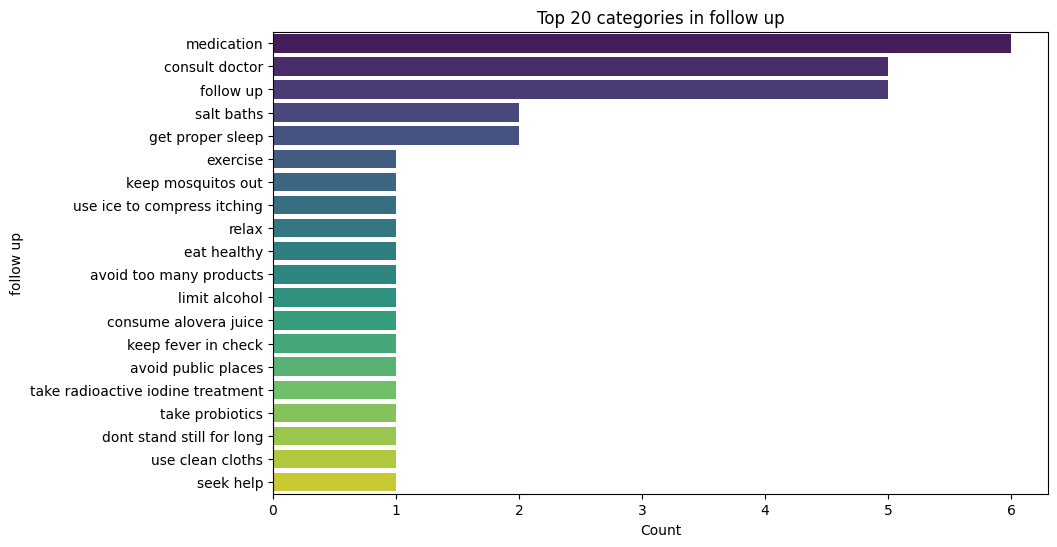

In [8]:
# Univariate Analysis
for col in df.columns:
    plt.figure(figsize=(10,6))
    if df[col].dtype == 'object':
        top_vals = df[col].value_counts().head(20)
        sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")
        plt.title(f"Top 20 categories in {col}")
        plt.xlabel("Count")
        plt.ylabel(col)
        plt.show()
    else:
        sns.histplot(df[col], kde=True, bins=30, color="royalblue")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

In [9]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10,6))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

In [10]:
# Categorical Crosstabs
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) >= 2:
    for i in range(len(cat_cols)-1):
        ct = pd.crosstab(df[cat_cols[i]], df[cat_cols[i+1]])
        print(f"\n🔹 Crosstab between {cat_cols[i]} and {cat_cols[i+1]}:\n", ct.head())


🔹 Crosstab between Drug Reaction                            and stop irritation                      :
 stop irritation                           Consult nearest hospital               \
Drug Reaction                                                                     
(vertigo) Paroymsal  Positional Vertigo                                       0   
AIDS                                                                          0   
Acne                                                                          0   
Alcoholic hepatitis                                                           0   
Allergy                                                                       0   

stop irritation                           acetaminophen                          \
Drug Reaction                                                                     
(vertigo) Paroymsal  Positional Vertigo                                       0   
AIDS                                                            

In [11]:
# Outlier Detection
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col], color="orange")
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

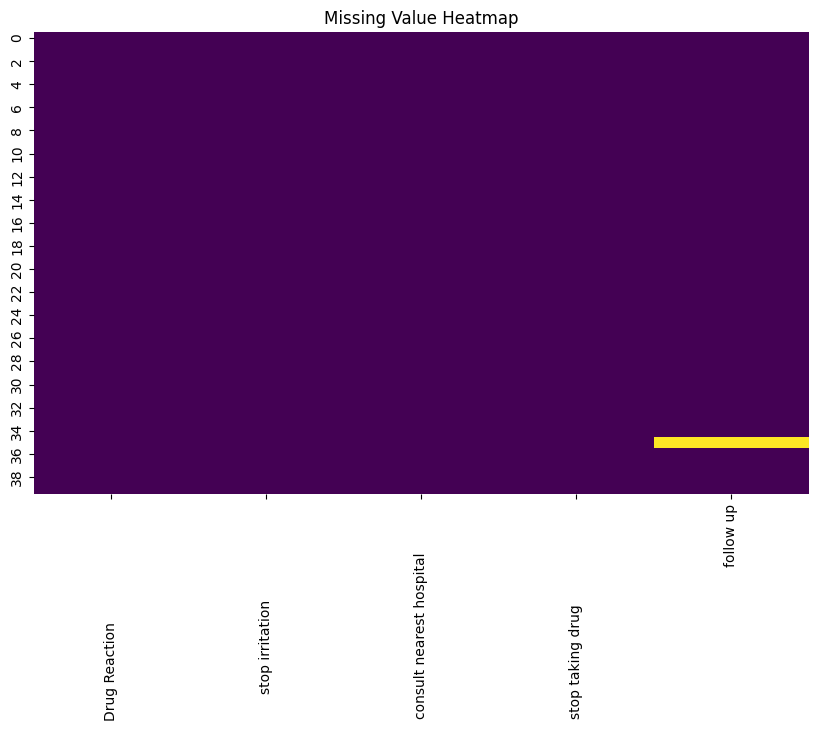

In [12]:
# Missing Data Pattern
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()


=== Boxplots for Each Feature ===


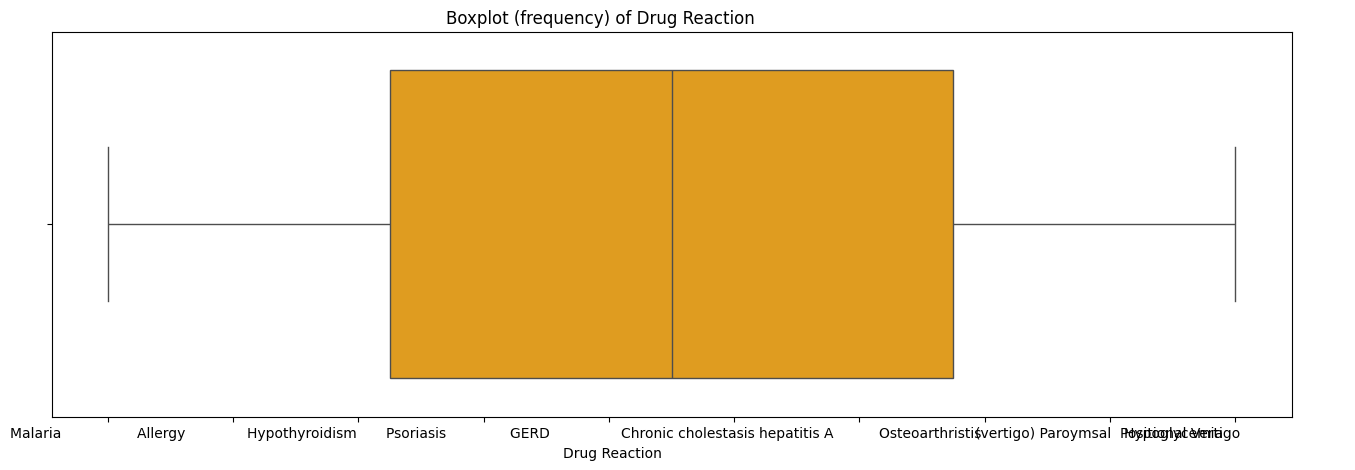

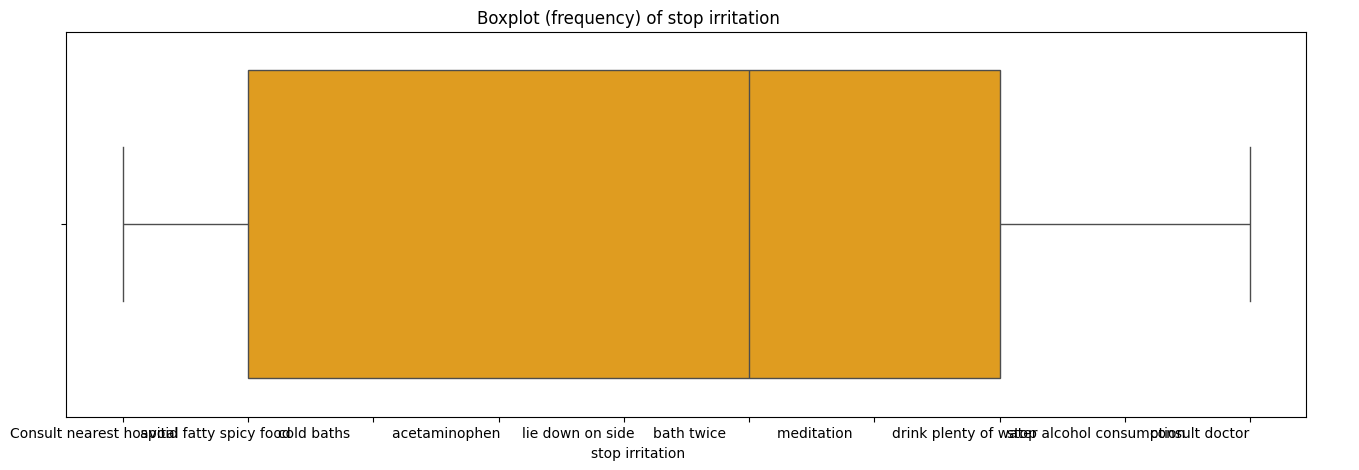

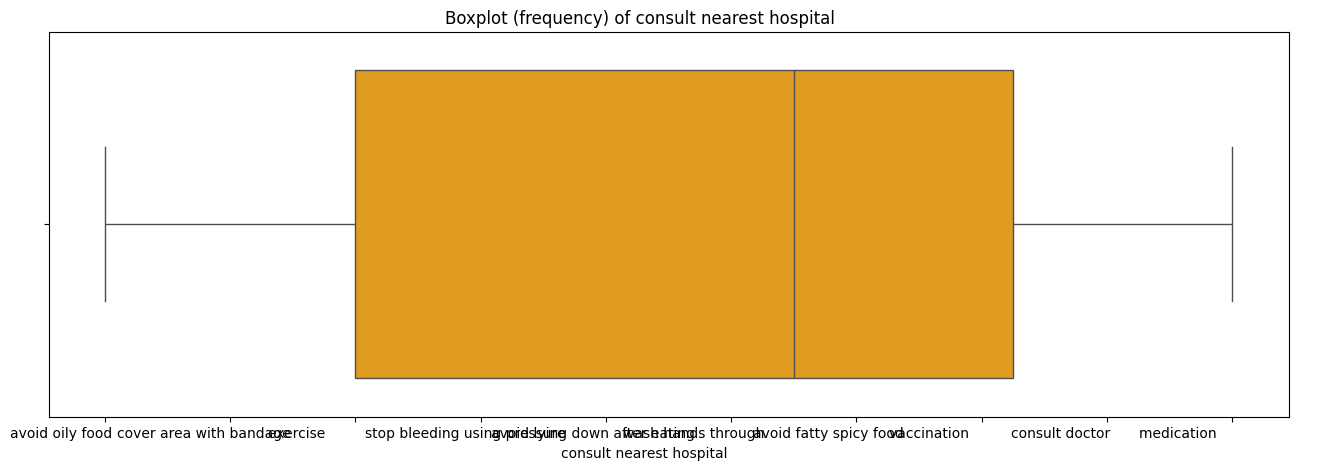

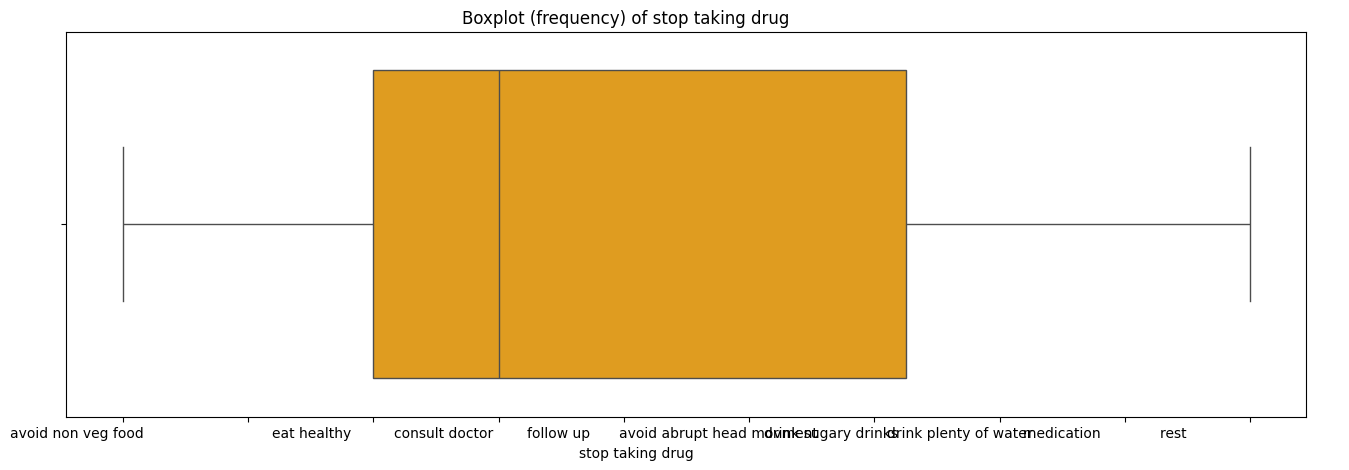

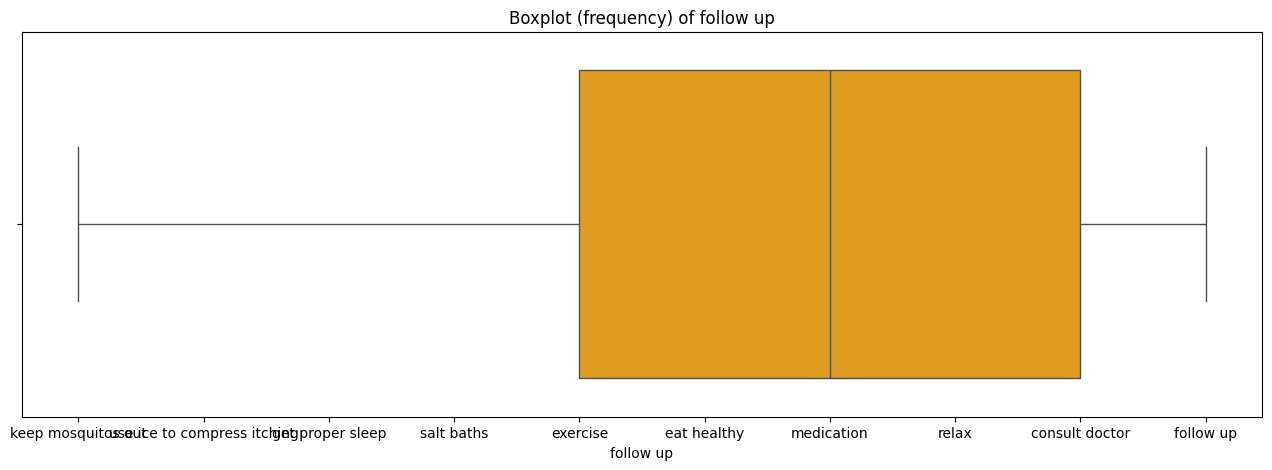

In [13]:
# Boxplots for Each Feature
print("\n=== Boxplots for Each Feature ===")

for col in df.columns:
    plt.figure(figsize=(16,5))
    if df[col].dtype != 'object':  # numeric features
        sns.boxplot(x=df[col], color="black")
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.show()
    else:  # categorical features
        top_vals = df[col].value_counts().head(10).index
        sns.boxplot(x=df[col][df[col].isin(top_vals)], color="orange")
        plt.title(f"Boxplot (frequency) of {col}")
        plt.xlabel(col)
        plt.show()


### EDA Completed Successfully!